# Non-Private Neural Network Training

Dataset: **Bank Marketing**

This notebook corresponds to **Section 4 "Non-private Modeling and Evaluation"**
of the paper. It loads the preprocessed dataset (`bank-processed.csv`,
produced by `03_data_preprocessing.ipynb`), performs the train/test split,
applies SMOTE-ENN to the training fold, runs Boruta feature selection
(Section 4.1), and trains a tuned feedforward neural network baseline
(Sections 4.2 and 4.3).

In [1]:
import random
from itertools import product
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    confusion_matrix,
    f1_score,
)
from imblearn.combine import SMOTEENN
from boruta import BorutaPy
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Paths
ROOT = Path.cwd().resolve()
DATA_PROCESSED = ROOT.parent / "data" / "processed"
FIG_DIR = ROOT.parent / "figures"
RES_DIR = ROOT.parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
data = pd.read_csv(DATA_PROCESSED / "bank-processed.csv")
print("Shape:", data.shape)

X = data.drop(columns=["y"])
Y = data["y"]


Shape: (45211, 33)


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=Y
)


In [4]:
# SMOTEENN for train
smoteenn = SMOTEENN(random_state=SEED)
X_resample, y_resample = smoteenn.fit_resample(X_train, y_train)
X_resample = pd.DataFrame(X_resample, columns=X.columns)
y_resample = pd.Series(y_resample)


In [5]:
# Class distribution before SMOTEENN
print("Total samples before SMOTEENN:", len(X))
print("Class distribution before SMOTEENN:")
print(y_train.value_counts())
# Print percentages
print("Class distribution percentages:")
print(y_train.value_counts(normalize=True) * 100)

# Check class distribution
print("total samples after SMOTEENN:", len(y_resample))
print("Class distribution after SMOTEENN:")
print(y_resample.value_counts())
# Print percentages
print("Class distribution percentages:")
print(y_resample.value_counts(normalize=True) * 100)

Total samples before SMOTEENN: 45211
Class distribution before SMOTEENN:
y
0    31937
1     4231
Name: count, dtype: int64
Class distribution percentages:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64
total samples after SMOTEENN: 53504
Class distribution after SMOTEENN:
y
1    27937
0    25567
Name: count, dtype: int64
Class distribution percentages:
y
1    52.214788
0    47.785212
Name: proportion, dtype: float64


In [6]:
# Feature Selection with BorutaPy
xgbc = xgb.XGBClassifier(eval_metric='logloss', random_state=SEED)
feat_selector = BorutaPy(xgbc, n_estimators='auto', verbose=0, random_state=SEED)
feat_selector.fit(X_resample.values, y_resample.values.ravel())
X_filtered = X.columns[feat_selector.support_].tolist()
print(f"Selected features: {len(X_filtered)}")


Selected features: 26


In [7]:
# Function to build the neural network model
def build_model(input_shape, learning_rate, dropout_rate, units, activation, hidden_layers):
    model = Sequential()
    model.add(Dense(units, activation=activation, input_shape=(input_shape,)))
    model.add(Dropout(dropout_rate))
    for _ in range(hidden_layers - 1):
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['AUC'])
    return model


In [8]:
# Define model
model = 'NeuralNetwork'

# Define hyperparameter grid
nn_grid = {'learning_rate': [0.0001, 0.001, 0.01], 'dropout_rate': [0.2, 0.3, 0.5], 'units': [64, 128, 256], 
                      'hidden_layers': [2, 3, 4]}


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `

Best params (NeuralNetwork): {'learning_rate': 0.0001, 'dropout_rate': 0.2, 'units': 64, 'hidden_layers': 2}
Best validation ROC AUC (NeuralNetwork): 0.000000


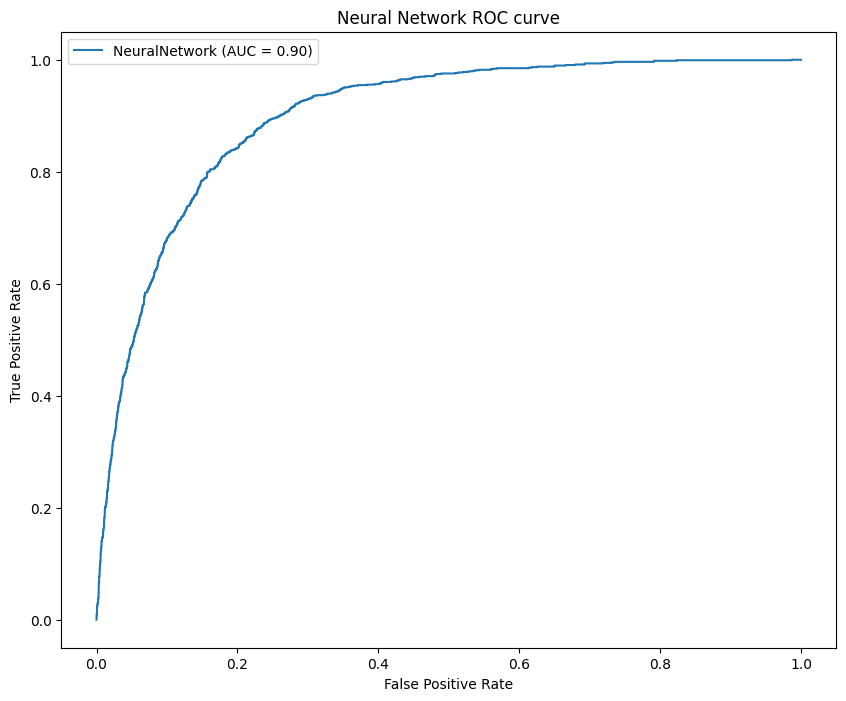


Resultados finales:


,Accuracy,Precision,Recall,F1 Score,Type I Error (%),Type II Error (%),ROC AUC,Best Params
0,0.837333,0.401807,0.798677,0.534641,15.75454,20.132325,0.898812,"{'learning_rate': 0.0001, 'dropout_rate': 0.2,..."


In [9]:
plt.figure(figsize=(10, 8))

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

best_score = -np.inf
best_params = None
best_nn_model = None

# Hyperparameter grid search
for lr, dr, units, hl in product(
    nn_grid['learning_rate'],
    nn_grid['dropout_rate'],
    nn_grid['units'],
    nn_grid['hidden_layers']
):
    nn_model = build_model(
        input_shape=len(X_filtered),
        learning_rate=lr,
        dropout_rate=dr,
        units=units,
        activation='relu',
        hidden_layers=hl
    )
    history = nn_model.fit(
        X_resample[X_filtered], y_resample,
        epochs=50, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    val_auc = max(history.history['val_AUC'])
    if val_auc > best_score:
        best_score = val_auc
        best_params = {
            'learning_rate': lr,
            'dropout_rate': dr,
            'units': units,
            'hidden_layers': hl
        }
        best_nn_model = nn_model

print(f'Best params (NeuralNetwork): {best_params}')
print(f'Best validation ROC AUC (NeuralNetwork): {best_score:.6f}')

# Predictions sobre test con el mejor modelo
y_prob = best_nn_model.predict(X_test[X_filtered], verbose=0).ravel()

# Evaluation
y_pred = (y_prob >= 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred)
actual_negatives = conf_matrix[0].sum()
actual_positives = conf_matrix[1].sum()
false_positive = conf_matrix[0][1]
false_negative = conf_matrix[1][0]
false_positive_pct = (false_positive / actual_negatives) * 100
false_negative_pct = (false_negative / actual_positives) * 100

# Results in a single dictionary (not indexed by model)
results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'Type I Error (%)': false_positive_pct,
    'Type II Error (%)': false_negative_pct,
    'ROC AUC': roc_auc_score(y_test, y_prob),
    'Best Params': best_params
}

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"NeuralNetwork (AUC = {results['ROC AUC']:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network ROC curve')
plt.legend()
plt.show()

# Tabla final (una sola fila)
results_df = pd.DataFrame([results])
print("\nResultados finales:")
results_df


In [10]:
results_df.to_csv(RES_DIR / "neural_network_results.csv")
